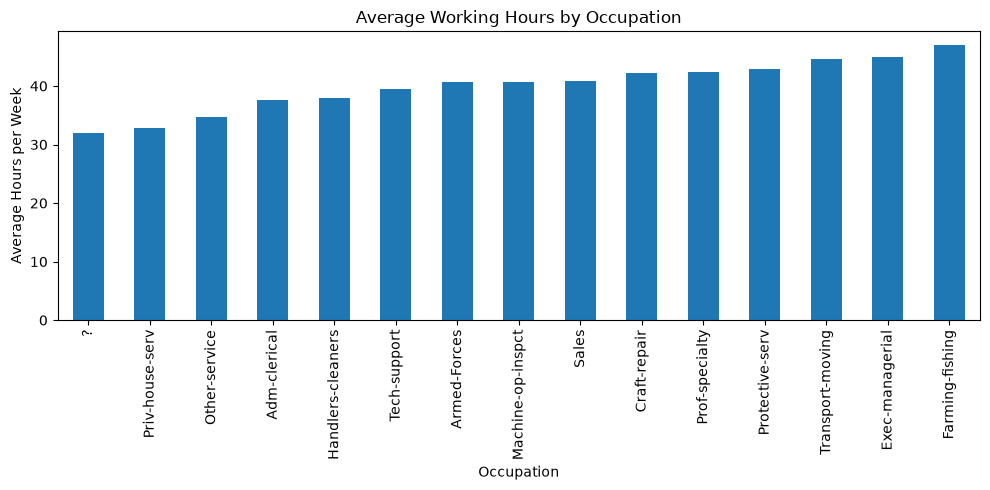

In [1]:
# Task 1 - Bar Chart
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('adult.csv')
df.columns = df.columns.str.replace('.', '-')

avg_hours = df.groupby('occupation')['hours-per-week'].mean().sort_values()
avg_hours.plot(kind='bar', figsize=(10, 5))
plt.xlabel('Occupation')
plt.ylabel('Average Hours per Week')
plt.title('Average Working Hours by Occupation')
plt.tight_layout()
plt.show()

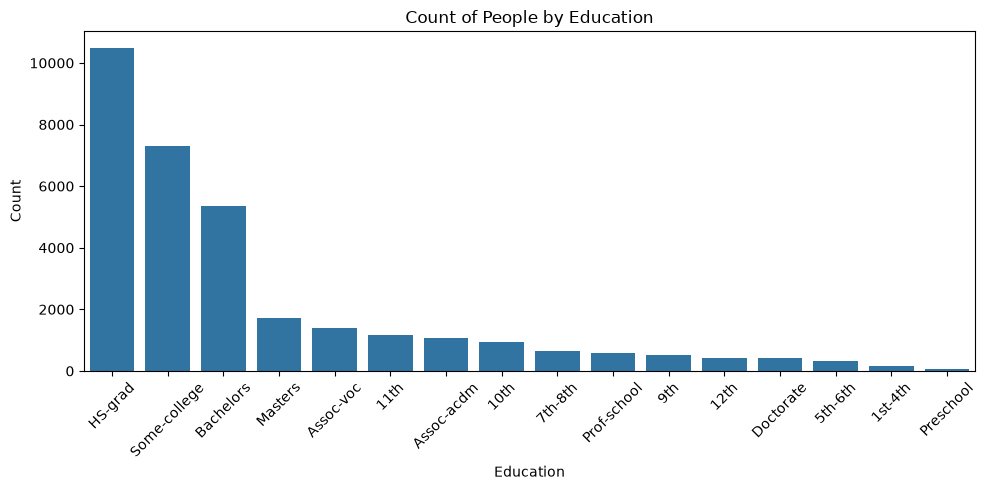

most common one is HS-grad


In [2]:
# Task 2 - Count Plot
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='education', order=df['education'].value_counts().index)
plt.xlabel('Education')
plt.ylabel('Count')
plt.title('Count of People by Education')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('most common one is', df['education'].value_counts().idxmax())

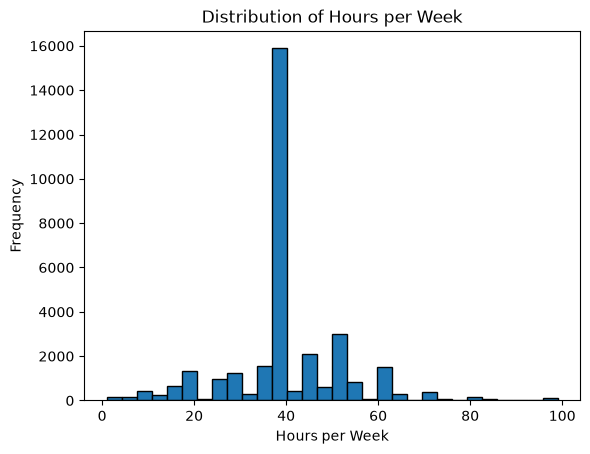

its right skewed, most values are around 40 but some are alot higher


In [3]:
# Task 3 - Histogram
plt.hist(df['hours-per-week'], bins=30, edgecolor='black')
plt.xlabel('Hours per Week')
plt.ylabel('Frequency')
plt.title('Distribution of Hours per Week')
plt.show()

print('its right skewed, most values are around 40 but some are alot higher')

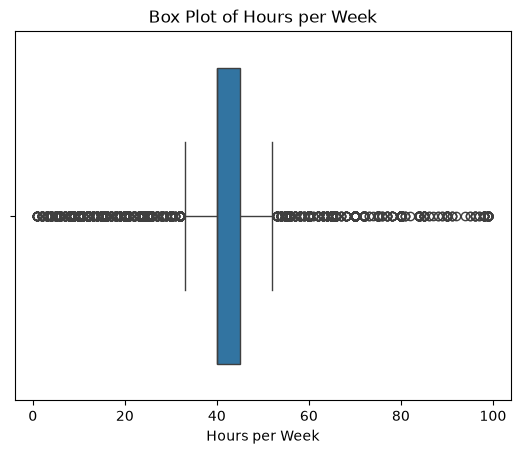

theres quite a few outliers on both sides


In [4]:
# Task 4 - Box Plot
sns.boxplot(x=df['hours-per-week'])
plt.xlabel('Hours per Week')
plt.title('Box Plot of Hours per Week')
plt.show()

print('theres quite a few outliers on both sides')

In [5]:
# Task 5 - IQR Method
Q1 = df['hours-per-week'].quantile(0.25)
Q3 = df['hours-per-week'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

lower_mask = df['hours-per-week'] < lower
upper_mask = df['hours-per-week'] > upper

lower_outliers = df[lower_mask]
upper_outliers = df[upper_mask]

outlier_mask = lower_mask | upper_mask
outliers = df[outlier_mask]

print('Q1 =', Q1)
print('Q3 =', Q3)
print('IQR =', IQR)
print('Lower bound =', lower)
print('Upper bound =', upper)
print('Lower outliers =', len(lower_outliers))
print('Upper outliers =', len(upper_outliers))
print('Number of outliers =', len(outliers))
print('this matches the box plot')

Q1 = 40.0
Q3 = 45.0
IQR = 5.0
Lower bound = 32.5
Upper bound = 52.5
Lower outliers = 5516
Upper outliers = 3492
Number of outliers = 9008
this matches the box plot


In [6]:
# Task 6 - Z-score Method
mean = df['hours-per-week'].mean()
std = df['hours-per-week'].std()

df['zscore'] = (df['hours-per-week'] - mean) / std
outliers_z = df[df['zscore'].abs() > 3]

print('IQR outliers:', len(outliers))
print('Z-score outliers:', len(outliers_z))
print('counts dont match since data is skewed, IQR uses quartiles and zscore uses mean and std')

IQR outliers: 9008
Z-score outliers: 440
counts dont match since data is skewed, IQR uses quartiles and zscore uses mean and std


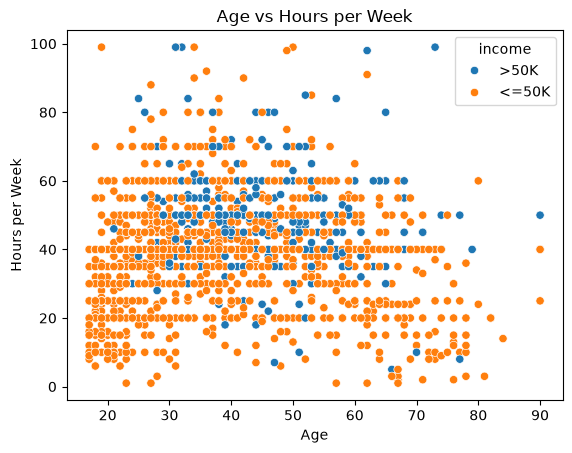

theres a very weak positive relation


In [7]:
# Task 7 - Scatter Plot
sns.scatterplot(data=df.sample(3000), x='age', y='hours-per-week', hue='income')
plt.xlabel('Age')
plt.ylabel('Hours per Week')
plt.title('Age vs Hours per Week')
plt.show()

print('theres a very weak positive relation')

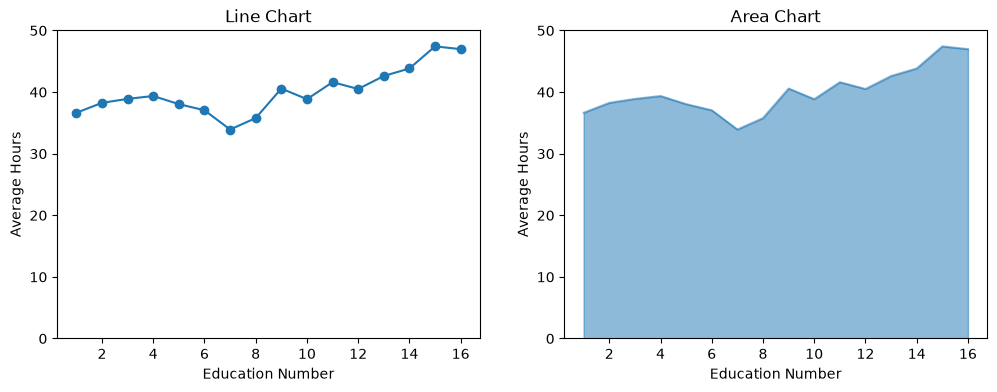

area chart makes values look bigger cuz the bottom is filled


In [8]:
# Task 8 - Line Chart and Area Chart
trend = df.groupby('education-num')['hours-per-week'].mean()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
trend.plot(kind='line', marker='o')
plt.xlabel('Education Number')
plt.ylabel('Average Hours')
plt.title('Line Chart')
plt.ylim(bottom=0, top=50)

plt.subplot(1, 2, 2)
trend.plot(kind='area', alpha=0.5)
plt.xlabel('Education Number')
plt.ylabel('Average Hours')
plt.title('Area Chart')
plt.ylim(bottom=0, top=50)

plt.show()

print('area chart makes values look bigger cuz the bottom is filled')

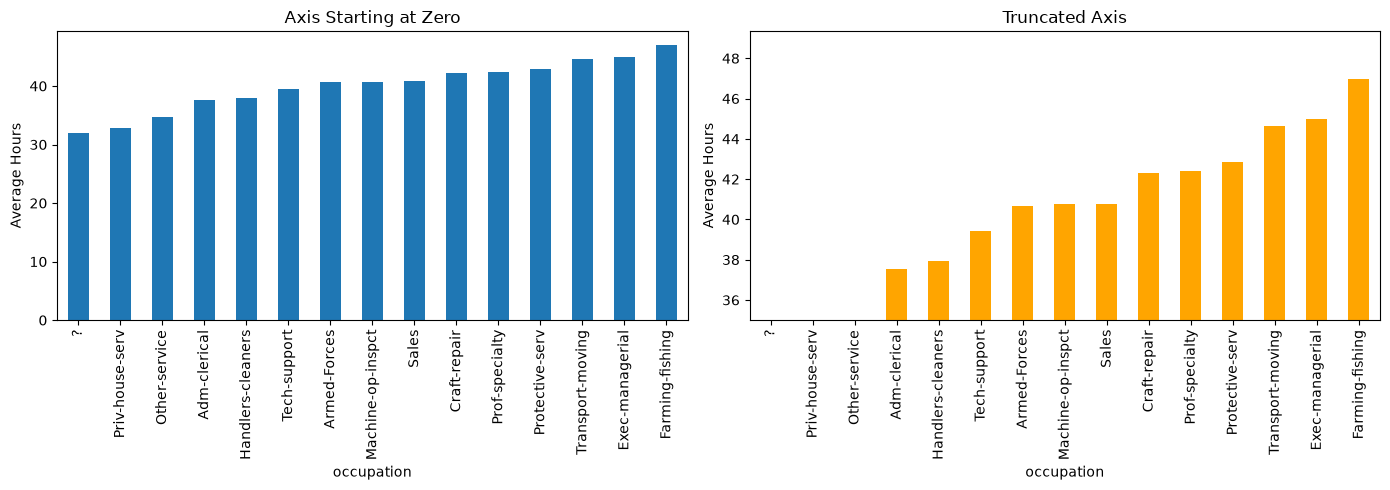

truncated axis makes small differences look way bigger, data is same tho


In [9]:
# Task 9 - Graphical Integrity
values = df.groupby('occupation')['hours-per-week'].mean().sort_values()

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
values.plot(kind='bar')
plt.ylim(bottom=0)
plt.title('Axis Starting at Zero')
plt.ylabel('Average Hours')

plt.subplot(1, 2, 2)
values.plot(kind='bar', color='orange')
plt.ylim(bottom=35)
plt.title('Truncated Axis')
plt.ylabel('Average Hours')

plt.tight_layout()
plt.show()

print('truncated axis makes small differences look way bigger, data is same tho')

df.drop(columns='zscore').to_csv('24I-2513_Lab2_cleaned.csv', index=False)